<a href="https://colab.research.google.com/github/Addreta/-fermi-hubbard-classical-benchmarks/blob/main/TENSOR_NETWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install physics-tenpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tenpy.networks.mps import MPS
from tenpy.models.hubbard import FermiHubbardModel

# Parameters
L = 4
t_hop = 1.0
U = 2.0

# Build Fermi-Hubbard model in TeNPy
model_params = {
    'L': L,
    't': t_hop,
    'U': U,
    'mu': 0.0,
    'V': 0.0,
    'bc_MPS': 'finite',
}
model = FermiHubbardModel(model_params)

# Build Neel initial state using from_product_state
sites = model.lat.mps_sites()
product_state = ['up', 'down', 'up', 'down']
psi = MPS.from_product_state(sites, product_state, bc='finite')

print(f"Initial bond dimensions: {psi.chi}")

# Measure initial Neel observable
sz_vals = psi.expectation_value('Sz')
print(f"Initial Sz per site: {sz_vals}")
neel_0 = sum(((-1)**i) * sz_vals[i] for i in range(L)) / L
print(f"Initial Neel value (should be 0.5): {neel_0:.4f}")

Initial bond dimensions: [1, 1, 1]
Initial Sz per site: [ 0.5 -0.5  0.5 -0.5]
Initial Neel value (should be 0.5): 0.5000


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


Running TDVP...
  t=1.00, m(t)=-0.0534, chi=[4, 16, 4]
  t=2.00, m(t)=-0.0222, chi=[4, 16, 4]
  t=3.00, m(t)=0.0373, chi=[4, 16, 4]
  t=4.00, m(t)=-0.1706, chi=[4, 16, 4]
  t=5.00, m(t)=-0.1431, chi=[4, 16, 4]
  t=6.00, m(t)=0.0334, chi=[4, 16, 4]
Done.


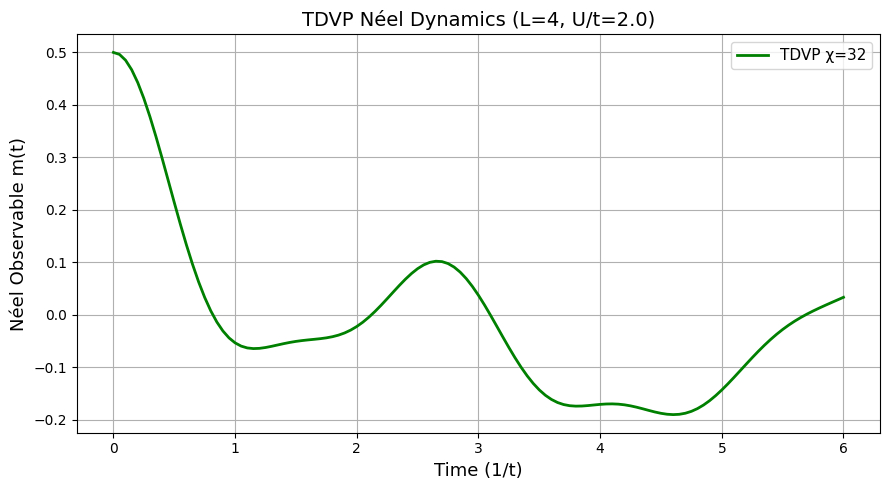

In [ ]:
from tenpy.algorithms.tdvp import TwoSiteTDVPEngine
import copy

# Time evolution parameters
dt = 0.05
t_max = 6.0
n_steps = int(t_max / dt)

# Storage
times = np.linspace(0, t_max, n_steps + 1)
neel_tdvp = [neel_0]

print("Running TDVP...")
for step in range(n_steps):
    # Reinitialize engine each step with N_steps=1
    tdvp_params = {
        'dt': dt,
        'N_steps': 1,
        'trunc_params': {
            'chi_max': 32,
            'svd_min': 1.e-10,
        },
    }
    engine = TwoSiteTDVPEngine(psi, model, tdvp_params)
    engine.run()

    sz_vals = psi.expectation_value('Sz')
    m = sum(((-1)**i) * sz_vals[i] for i in range(L)) / L
    neel_tdvp.append(m)

    if (step + 1) % 20 == 0:
        print(f"  t={(step+1)*dt:.2f}, m(t)={m:.4f}, chi={psi.chi}")

print("Done.")

# Plot
plt.figure(figsize=(9, 5))
plt.plot(times, neel_tdvp, 'g-', linewidth=2, label='TDVP χ=32')
plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'TDVP Néel Dynamics (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('tdvp_neel.png', dpi=150)
plt.show()

In [ ]:
!pip install quspin openfermion qiskit qiskit-aer qiskit-nature qiskit-algorithms physics-tenpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.5/38.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.7 MB/s eta 0:00:00
  Created wheel for 

/usr/local/lib/python3.12/dist-packages/tenpy/tools/params.py:243: UserWarning: unused options for config TwoSiteTDVPEngine:
['N_steps', 'dt']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))
/usr/local/lib/python3.12/dist-packages/tenpy/tools/params.py:243: UserWarning: unused options for config trunc_params:
['chi_max', 'svd_min']
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))


Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!


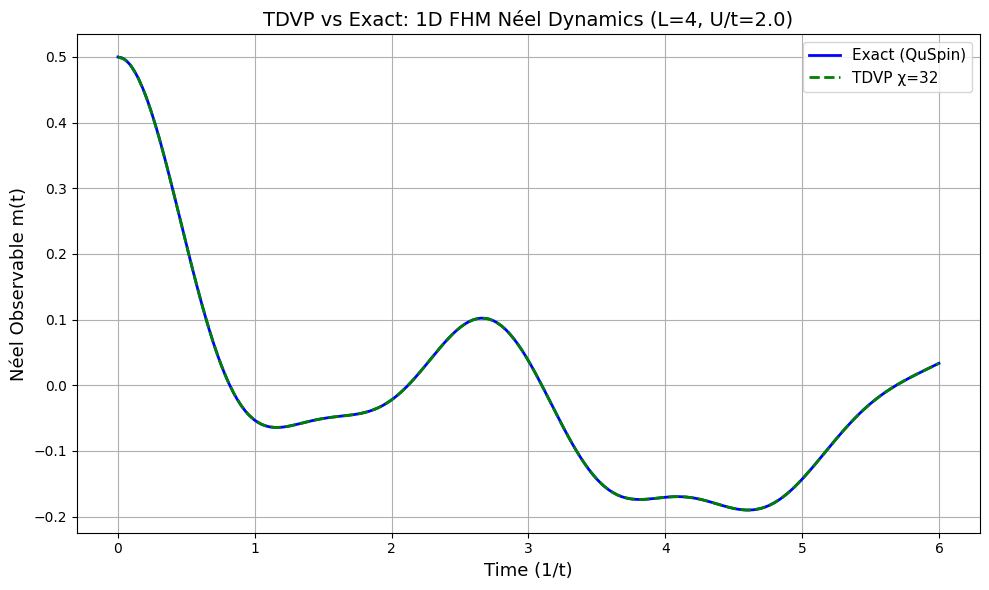

Max error (TDVP vs exact): 0.000302


In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d
import numpy as np
import matplotlib.pyplot as plt

# Exact solution via QuSpin
basis = spinful_fermion_basis_1d(L, Nf=(2, 2))
hop = [[-t_hop, i, i+1] for i in range(L-1)] + [[-t_hop, i+1, i] for i in range(L-1)]
interaction = [[U, i, i] for i in range(L)]
static = [["+-|", hop], ["|+-", hop], ["n|n", interaction]]
H = hamiltonian(static, [], basis=basis, dtype=np.complex128)

# Neel initial state
neel_state = basis.index("1010", "0101")
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[neel_state] = 1.0

# Build Sz operators
def build_Sz(site, basis):
    static_sz = [["n|", [[0.5, site]]], ["|n", [[-0.5, site]]]]
    return hamiltonian(static_sz, [], basis=basis, dtype=np.complex128,
                       check_symm=False, check_herm=False, check_pcon=False)

Sz_ops = [build_Sz(i, basis) for i in range(L)]

# Time evolve
times_exact = np.linspace(0, t_max, 200)
psi_t = H.evolve(psi0, 0, times_exact)
neel_exact = np.zeros(len(times_exact))
for i in range(L):
    Sz_expect = np.real(np.einsum('it,ij,jt->t',
                        psi_t.conj(), Sz_ops[i].toarray(), psi_t))
    neel_exact += ((-1)**i) * Sz_expect
neel_exact /= L

# Plot both
plt.figure(figsize=(10, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2, label='Exact (QuSpin)')
plt.plot(times, neel_tdvp, 'g--', linewidth=2, label='TDVP χ=32')
plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'TDVP vs Exact: 1D FHM Néel Dynamics (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('tdvp_vs_exact.png', dpi=150)
plt.show()

# Print error
neel_tdvp_arr = np.array(neel_tdvp)
neel_exact_interp = np.interp(times, times_exact, neel_exact)
max_error = np.max(np.abs(neel_tdvp_arr - neel_exact_interp))
print(f"Max error (TDVP vs exact): {max_error:.6f}")

/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=1 done


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=2 done


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=4 done


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=8 done


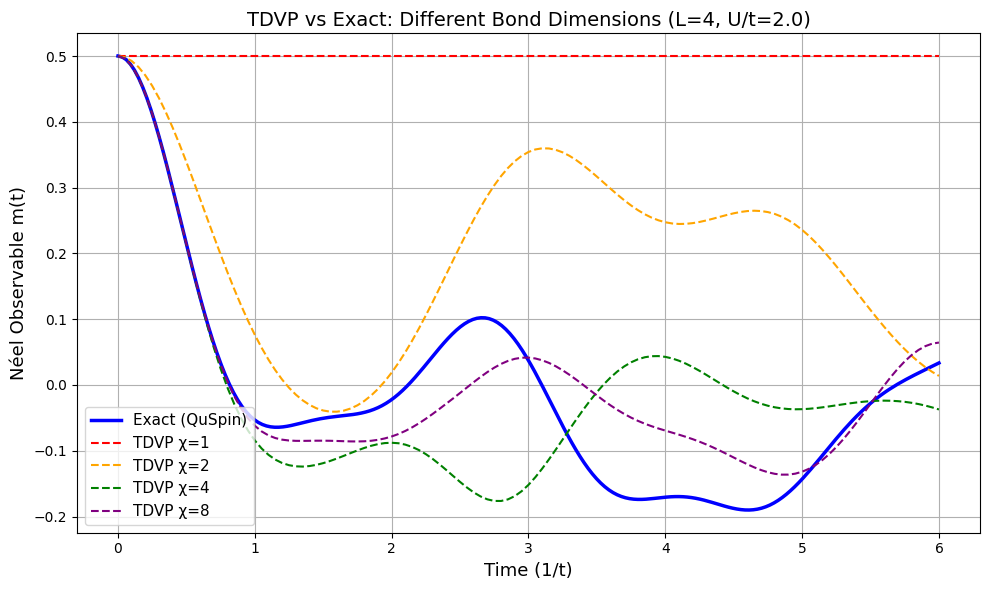

In [ ]:
from tenpy.algorithms.tdvp import TwoSiteTDVPEngine
import numpy as np
import matplotlib.pyplot as plt

chi_values = [1, 2, 4, 8]
colors = ['red', 'orange', 'green', 'purple']

plt.figure(figsize=(10, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2.5, label='Exact (QuSpin)')

for chi, color in zip(chi_values, colors):
    # Reinitialize fresh psi each time
    psi_chi = MPS.from_product_state(sites, ['up', 'down', 'up', 'down'], bc='finite')
    neel_chi = [0.5]

    for step in range(n_steps):
        tdvp_params = {
            'dt': dt,
            'N_steps': 1,
            'trunc_params': {
                'chi_max': chi,
                'svd_min': 1.e-10,
            },
        }
        engine = TwoSiteTDVPEngine(psi_chi, model, tdvp_params)
        engine.run()
        sz_vals = psi_chi.expectation_value('Sz')
        m = sum(((-1)**i) * sz_vals[i] for i in range(L)) / L
        neel_chi.append(m)

    plt.plot(times, neel_chi, color=color, linestyle='--',
             linewidth=1.5, label=f'TDVP χ={chi}')
    print(f"χ={chi} done")

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'TDVP vs Exact: Different Bond Dimensions (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('tdvp_chi_comparison.png', dpi=150)
plt.show()

Exact Neel at t=4.0: -0.170644


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=  1: m(t)=0.500000, error=0.670644


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ=  2: m(t)=0.247340, error=0.417984


...

χ=  8: m(t)=-0.069354, error=0.101290


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ= 16: m(t)=-0.170631, error=0.000013


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


χ= 32: m(t)=-0.170631, error=0.000013


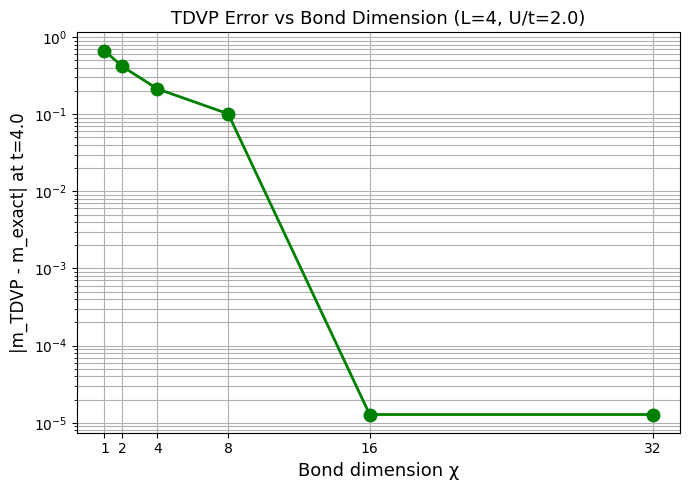

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tenpy.networks.mps import MPS
from tenpy.algorithms.tdvp import TwoSiteTDVPEngine

# Fixed time to measure error
t_fixed = 4.0
n_steps_fixed = int(t_fixed / dt)

# Exact Neel value at t_fixed
neel_exact_t = np.interp(t_fixed, times_exact, neel_exact)
print(f"Exact Neel at t={t_fixed}: {neel_exact_t:.6f}")

# Chi values to test
chi_values = [1, 2, 4, 8, 16, 32]
errors = []

for chi in chi_values:
    psi_chi = MPS.from_product_state(sites, ['up', 'down', 'up', 'down'], bc='finite')

    for step in range(n_steps_fixed):
        tdvp_params = {
            'dt': dt,
            'N_steps': 1,
            'trunc_params': {
                'chi_max': chi,
                'svd_min': 1.e-10,
            },
        }
        engine = TwoSiteTDVPEngine(psi_chi, model, tdvp_params)
        engine.run()

    sz_vals = psi_chi.expectation_value('Sz')
    m = sum(((-1)**i) * sz_vals[i] for i in range(L)) / L
    error = abs(m - neel_exact_t)
    errors.append(error)
    print(f"χ={chi:3d}: m(t)={m:.6f}, error={error:.6f}")

# Plot
plt.figure(figsize=(7, 5))
plt.semilogy(chi_values, errors, 'go-', linewidth=2, markersize=9)
plt.xlabel('Bond dimension χ', fontsize=13)
plt.ylabel(f'|m_TDVP - m_exact| at t={t_fixed}', fontsize=12)
plt.title(f'TDVP Error vs Bond Dimension (L={L}, U/t={U})', fontsize=13)
plt.xticks(chi_values)
plt.grid(True, which='both')
plt.tight_layout()
plt.savefig('tdvp_error_vs_chi.png', dpi=150)
plt.show()

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!
Exact done.
1st order Trotter done.
2nd order Trotter done.


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


TDVP χ=4 done.


/usr/local/lib/python3.12/dist-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


TDVP χ=16 done.


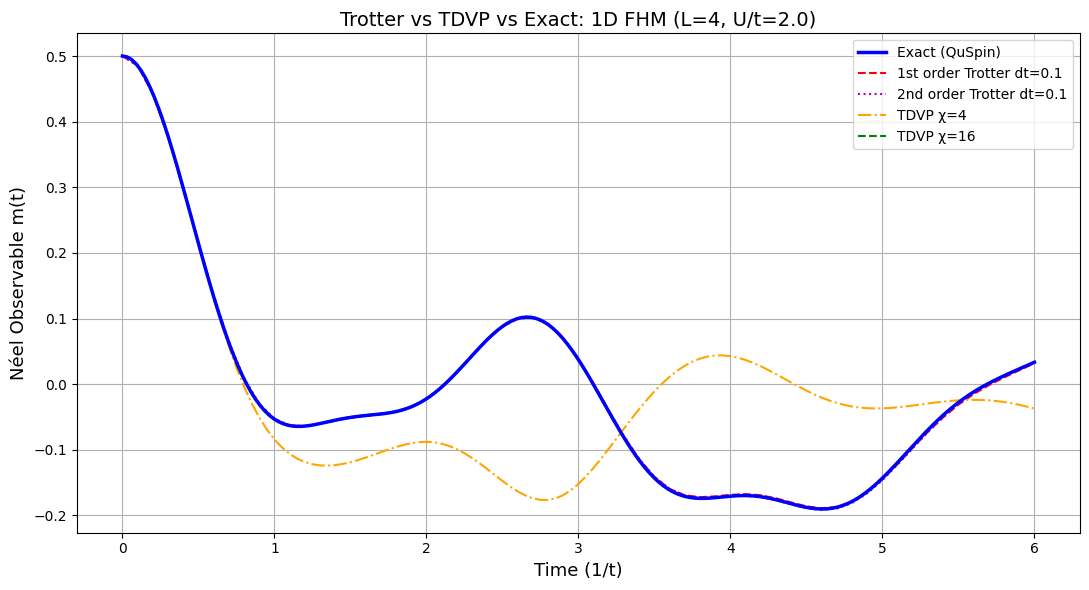

In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d
from tenpy.networks.mps import MPS
from tenpy.algorithms.tdvp import TwoSiteTDVPEngine
from scipy.linalg import expm
from qiskit.quantum_info import SparsePauliOp
from openfermion.hamiltonians import fermi_hubbard
from openfermion.transforms import jordan_wigner
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
L = 4
t_hop = 1.0
U = 2.0
t_max = 6.0
dt = 0.05
n_steps = int(t_max / dt)
times = np.linspace(0, t_max, n_steps + 1)

# --- 1. Exact (QuSpin) ---
basis = spinful_fermion_basis_1d(L, Nf=(2, 2))
hop = [[-t_hop, i, i+1] for i in range(L-1)] + [[-t_hop, i+1, i] for i in range(L-1)]
interaction = [[U, i, i] for i in range(L)]
static = [["+-|", hop], ["|+-", hop], ["n|n", interaction]]
H_quspin = hamiltonian(static, [], basis=basis, dtype=np.complex128)

neel_state = basis.index("1010", "0101")
psi0_qs = np.zeros(basis.Ns, dtype=np.complex128)
psi0_qs[neel_state] = 1.0

def build_Sz(site, basis):
    static_sz = [["n|", [[0.5, site]]], ["|n", [[-0.5, site]]]]
    return hamiltonian(static_sz, [], basis=basis, dtype=np.complex128,
                       check_symm=False, check_herm=False, check_pcon=False)

Sz_ops = [build_Sz(i, basis) for i in range(L)]

times_exact = np.linspace(0, t_max, 200)
psi_t = H_quspin.evolve(psi0_qs, 0, times_exact)
neel_exact = np.zeros(len(times_exact))
for i in range(L):
    Sz_expect = np.real(np.einsum('it,ij,jt->t',
                        psi_t.conj(), Sz_ops[i].toarray(), psi_t))
    neel_exact += ((-1)**i) * Sz_expect
neel_exact /= L
print("Exact done.")

# --- 2. Trotter (1st and 2nd order) ---
def openfermion_to_qiskit(qubit_operator, n_qubits):
    pauli_list = []
    for term, coeff in qubit_operator.terms.items():
        if abs(coeff) < 1e-10:
            continue
        pauli_str = ['I'] * n_qubits
        for qubit_idx, pauli in term:
            pauli_str[qubit_idx] = pauli
        pauli_str = ''.join(reversed(pauli_str))
        pauli_list.append((pauli_str, coeff.real))
    return SparsePauliOp.from_list(pauli_list)

n_qubits = 2 * L
fh_op = fermi_hubbard(x_dimension=L, y_dimension=1,
                       tunneling=t_hop, coulomb=U, periodic=False)
jw_op = jordan_wigner(fh_op)
H_qiskit = openfermion_to_qiskit(jw_op, n_qubits)
H_matrix = H_qiskit.to_matrix()

pauli_list_q = H_qiskit.to_list()
H_hop_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list_q
                                         if 'X' in p or 'Y' in p]).to_matrix()
H_int_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list_q
                                         if 'X' not in p and 'Y' not in p]).to_matrix()

def build_Sz_matrix(site, n_qubits):
    up_qubit   = 2 * site
    down_qubit = 2 * site + 1
    up_str   = 'I'*(n_qubits-up_qubit-1)   + 'Z' + 'I'*up_qubit
    down_str = 'I'*(n_qubits-down_qubit-1) + 'Z' + 'I'*down_qubit
    return SparsePauliOp.from_list([(up_str, -0.25),
                                    (down_str, 0.25)]).to_matrix()

Sz_matrices = [build_Sz_matrix(i, n_qubits) for i in range(L)]

def measure_neel(psi):
    return sum(((-1)**i) * np.real(psi.conj() @ Sz_matrices[i] @ psi)
               for i in range(L)) / L

qc_init = QuantumCircuit(n_qubits)
for q in [0, 4, 3, 7]:
    qc_init.x(q)
psi0_q = Statevector(qc_init).data

dt_trotter = 0.1

# 1st order
U_hop_1 = expm(-1j * dt_trotter * H_hop_matrix)
U_int_1 = expm(-1j * dt_trotter * H_int_matrix)
psi = psi0_q.copy()
neel_1st = [measure_neel(psi)]
times_tr = [0.0]
for step in range(int(t_max / dt_trotter)):
    psi = U_int_1 @ (U_hop_1 @ psi)
    neel_1st.append(measure_neel(psi))
    times_tr.append((step+1) * dt_trotter)
print("1st order Trotter done.")

# 2nd order
U_hop_half = expm(-1j * (dt_trotter/2) * H_hop_matrix)
U_int_full = expm(-1j * dt_trotter * H_int_matrix)
psi = psi0_q.copy()
neel_2nd = [measure_neel(psi)]
for step in range(int(t_max / dt_trotter)):
    psi = U_hop_half @ (U_int_full @ (U_hop_half @ psi))
    neel_2nd.append(measure_neel(psi))
print("2nd order Trotter done.")

# --- 3. TDVP at different chi ---
model_params = {'L': L, 't': t_hop, 'U': U,
                'mu': 0.0, 'V': 0.0, 'bc_MPS': 'finite'}
from tenpy.models.hubbard import FermiHubbardModel
model = FermiHubbardModel(model_params)
sites = model.lat.mps_sites()

tdvp_results = {}
for chi in [4, 16]:
    psi_chi = MPS.from_product_state(sites, ['up','down','up','down'], bc='finite')
    neel_chi = [0.5]
    for step in range(n_steps):
        engine = TwoSiteTDVPEngine(psi_chi, model, {
            'dt': dt, 'N_steps': 1,
            'trunc_params': {'chi_max': chi, 'svd_min': 1e-10}})
        engine.run()
        sz_vals = psi_chi.expectation_value('Sz')
        m = sum(((-1)**i) * sz_vals[i] for i in range(L)) / L
        neel_chi.append(m)
    tdvp_results[chi] = neel_chi
    print(f"TDVP χ={chi} done.")

# --- Combined Plot ---
plt.figure(figsize=(11, 6))
plt.plot(times_exact, neel_exact, 'b-',  linewidth=2.5, label='Exact (QuSpin)', zorder=5)
plt.plot(times_tr,    neel_1st,   'r--', linewidth=1.5, label=f'1st order Trotter dt={dt_trotter}')
plt.plot(times_tr,    neel_2nd,   'm:',  linewidth=1.5, label=f'2nd order Trotter dt={dt_trotter}')
plt.plot(times, tdvp_results[4],  'orange',  linestyle='-.', linewidth=1.5, label='TDVP χ=4')
plt.plot(times, tdvp_results[16], 'g--', linewidth=1.5, label='TDVP χ=16')

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Trotter vs TDVP vs Exact: 1D FHM (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('trotter_tdvp_exact.png', dpi=150)
plt.show()

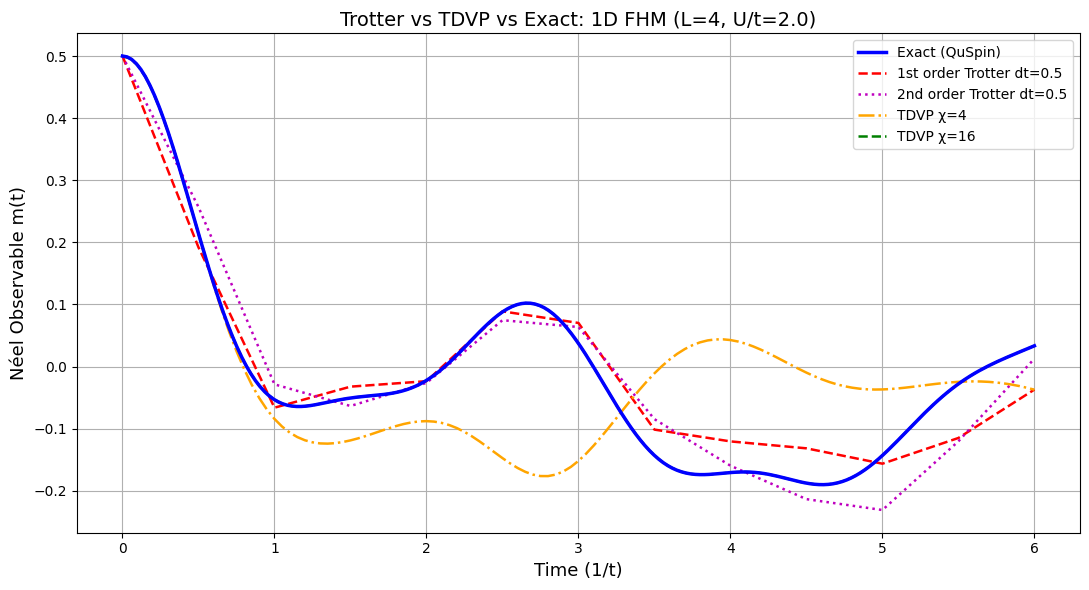

In [ ]:
# --- Combined Plot with visible differences ---
plt.figure(figsize=(11, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2.5, label='Exact (QuSpin)', zorder=5)

# Trotter with larger dt to show error
dt_large = 0.5
U_hop_l = expm(-1j * dt_large * H_hop_matrix)
U_int_l = expm(-1j * dt_large * H_int_matrix)
U_hop_half_l = expm(-1j * (dt_large/2) * H_hop_matrix)
U_int_full_l = expm(-1j * dt_large * H_int_matrix)

psi = psi0_q.copy()
neel_1st_large = [measure_neel(psi)]
times_large = [0.0]
for step in range(int(t_max / dt_large)):
    psi = U_int_l @ (U_hop_l @ psi)
    neel_1st_large.append(measure_neel(psi))
    times_large.append((step+1) * dt_large)

psi = psi0_q.copy()
neel_2nd_large = [measure_neel(psi)]
for step in range(int(t_max / dt_large)):
    psi = U_hop_half_l @ (U_int_full_l @ (U_hop_half_l @ psi))
    neel_2nd_large.append(measure_neel(psi))

plt.plot(times_large, neel_1st_large, 'r--',  linewidth=1.8,
         label=f'1st order Trotter dt={dt_large}')
plt.plot(times_large, neel_2nd_large, 'm:',   linewidth=1.8,
         label=f'2nd order Trotter dt={dt_large}')
plt.plot(times, tdvp_results[4],  color='orange', linestyle='-.', linewidth=1.8,
         label='TDVP χ=4')
plt.plot(times, tdvp_results[16], 'g--', linewidth=1.8,
         label='TDVP χ=16')

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Trotter vs TDVP vs Exact: 1D FHM (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('trotter_tdvp_exact_final.png', dpi=150)
plt.show()